# 08 — Tuning

**You can compute a starting gain set from a single step test, without a model.**

Every gain in notebooks 03 to 05 was handed over without explanation. This notebook is where
they come from, and it is the practical task from slide 15: study the system, apply a tuning
method, find suitable constants.

Three methods, two experiments. **Cohen-Coon** reads three numbers off an open-loop step test
and never leaves the stable region. **Ziegler-Nichols** and **Tyreus-Luyben** close the loop
under proportional control, raise the gain until the car oscillates and will not stop, and read
two numbers off that. All three then look the gains up in a table someone fitted decades ago to
plants that were not this car — and none of them ever uses the mass, the drag area or the gear
ratio.

**The ending is not tidy, and it is not meant to be.** None of the three gain sets fits inside
the engine this car has: Ziegler-Nichols asks for nine times the torque available,
Tyreus-Luyben seven times, Cohen-Coon nearly three. That is arithmetic rather than a modeling
defect, and the last three sections are about what it means and what to do instead.

Speeds are in km/h everywhere, and so is the loop — setpoint, measurement and error — which
makes every gain a number in N.m per km/h.


## Setup

`support.jl` carries the boilerplate shared by all ten notebooks: the environment bootstrap,
the parameter set, the sweep machinery, and the plotting and readout conventions. It carries no
physics.

`tuning_tables.jl` carries the three tables, transcribed from
`materials/ControlTheory/tuning_methods.pdf`. Every coefficient in it is checked against a
value computed by hand in `test/tuning_tables.jl`, because a mis-copied coefficient is exactly
the kind of mistake that produces a plausible gain and no complaint at all.


In [1]:
isdefined(Main, :Lecture01Support) || include("support.jl")

# Bound by hand rather than with `using`. If this kernel ever ran an earlier `include` of
# support.jl there are two copies of the module, every name both export is ambiguous, and no
# amount of re-running `using` resolves it. An explicit binding does, so this cell repairs a
# kernel in that state instead of needing it restarted. Editing support.jl still needs a
# restart, because the guard above deliberately will not load a second copy.
for n in names(Lecture01Support)
    n === :Lecture01Support && continue
    Core.eval(Main, :($n = Lecture01Support.$n))
end

isdefined(Main, :TuningTables) || include("tuning_tables.jl")
using .TuningTables

In [2]:
setup()

Main.VehicleSystemsComponents

## 1. Before any table: is this system well behaved?

The tuning guide opens with a gate rather than a formula, and the gate matters more than
anything below it. A system is **not** well behaved if any of these is true of it:

| Not well behaved | Why the methods below fail |
|---|---|
| strongly nonlinear | one set of linear gains cannot serve the whole operating range |
| unstable, and you are trying to stabilize it | there is no open-loop step response to measure, and no stable gain to walk up from |
| dead-time dominated | PID has no mechanism for acting on information it does not have yet; you want a predictor |
| non-minimum phase | the output initially moves the wrong way, and feedback pushes harder in response |

In each of those cases these methods may still work, but you are past what they were fitted
for. This car is on the comfortable side of all four:

| | This car |
|---|---|
| **stable open loop** | yes — notebook 01 ran it to a steady speed at constant torque |
| **near enough linear** | yes over a 20 km/h window: drag is quadratic, so the local time constant moves from 74 s at 90 km/h to 61 s at 110, and nothing worse than that happens |
| **minimum phase** | yes — more torque never makes the car go slower first |
| **manageable delay** | yes — section 2 measures `theta/tau` at 0.03, at the easy end of a scale that only becomes difficult above 1 |

Then the second question, which decides *which* methods you are allowed to use:

| You have | You can |
|---|---|
| hardware only | guess and check; or run a step test and use a heuristic table |
| a model | pole placement, loop shaping, autotuning — or the same heuristic tables, without risking the hardware |

**We have a model, and we are going to use the hardware methods on it anyway.** Two reasons.
Those are the methods that transfer to a plant nobody has modeled, which is most plants. And
running Ziegler-Nichols on a model is the only way to run Ziegler-Nichols on a car at all
without driving a real one to the edge of instability — section 7 is about the price of that
convenience.


## 2. The open-loop step test

All three tables describe the plant as first order plus dead time:

$$
G(s) \;=\; \frac{K\,e^{-\theta s}}{\tau s + 1}
$$

Three numbers, and not one of them is a property of a *car*. `K` is how far the output moves
per unit of input once everything has settled, `tau` is how long it takes to get there, and
`theta` is how long nothing happens first. It is a model of a *shape*, and a great many
industrial plants have that shape.

Slide 7's procedure, which is also step 1 of Cohen-Coon in `tuning_methods.pdf`:

1. **Wait until the process is at rest.** The harness starts the car settled at 90 km/h with
   the engine already delivering the torque that holds it, which is the state notebook 01
   computed on paper.
2. **Put the controller in manual.** There is no controller anywhere in this section.
3. **Change the manipulated variable rapidly.** Step the torque from the value that holds
   90 km/h to the value that holds 110.
4. **Record the response and scale it by the size of the step.** That division is what makes
   `K` a property of the plant rather than of how hard we happened to push it.

Then the construction the document specifies for turning that curve into three numbers: find
the times at which the output has covered half and $1 - 1/e$ of its total change $B$, and
extrapolate the straight line those two points imply back to the pre-step level.

$$
t_1 = \frac{t_2 - \ln 2 \cdot t_3}{1 - \ln 2}, \qquad
K = \frac{B}{A}, \qquad \tau = t_3 - t_1, \qquad \theta = t_1 - t_0
$$

`fopdt_fit` in `support.jl` is exactly that, with the exact constants rather than the
document's rounded `0.632`: $t_1$ magnifies an error in either landmark by about 2.3 time
constants, so on a `tau` of a minute that rounding alone invents a third of a second of dead
time.

This is the same experiment as notebook 01, against the same harness with the same two torques,
so the three numbers have to come out the same. A practitioner would have these and nothing
else.


In [3]:
show_dyad("CarStepTest")

CarStepTest — dyad/Lecture1/CarStepTest.dyad line 1 
 """
Open-loop torque step from one cruise to another, on flat road.

The step test of notebook 01: hold a low cruise torque, then step to a higher one and read
K, tau and theta off the speed response. The two torques are the cruise values the notebook
derives from the steady-state force balance on paper — `tau_lo` holds 90 km/h, `tau_hi` holds
110 km/h — and are exposed as parameters so the step test literally runs the equation the
students just wrote down.

The lag state starts at `tau_lo` and the speed at its matching cruise value, so the car begins
in equilibrium. Without that the run would burn hundreds of seconds settling before the step,
since the vehicle's own time constant is about 60 s.
"""
component CarStepTest
 "Cruise torque before the step (holds 90 km/h)"
 parameter tau_lo::Torque = 31.078
 "Cruise torque after the step (holds 110 km/h)"
 parameter tau_hi::Torque = 40.119
 "Initial speed, matching the tau_lo cruise (25 m/s = 90 km/h)"
 parameter v0::Velocity = 25.0
 "Time of the torque step"
 parameter t_step::Time = 50.0
 plant = VehicleSystemsComponents.Vehicle.CarPlant()
 cmd = BlockComponents.Sources.Step(offset = tau_lo, height = tau_hi - tau_lo, start_time = t_step)
 "Flat road"
 road = BlockComponents.Sources.Constant(k = 0.0)
relations
 connect(cmd.y, plant.tau_cmd)
 connect(road.y, plant.grade)
 initial plant.body.mass.s = 0.0
 initial plant.body.mass.v = v0
 initial plant.engine.lag.x = tau_lo
metadata {
 "Dyad": {
 "tests": {
 "case1": {
 "stop": 500,
 "atol": {"plant.v_kmh": 0.05, "plant.engine.limiter.y": 0.001},
 "expect": {
 "initial": {"plant.v_kmh": 90.0, "plant.engine.limiter.y": 31.078},
 "final": {"plant.v_kmh": 110.0, "plant.engine.limiter.y": 40.119},
 "signals": ["plant.v_kmh", "plant.engine.limiter.y", "cmd.y"]
 }
 }
 }
 }
}
end

In [4]:
Scenarios = VehicleSystemsComponents.Lecture1

# The two torques are the force balance of notebook 01 solved for torque at each end of the
# step, and the harness takes them as parameters — so the step test runs that equation rather
# than a rounded copy of it.
c_drag = 0.5 * CAR.rho * CAR.CdA                            # N per (m/s)^2
F_roll = CAR.f_r * CAR.m * CAR.g                            # N, flat road
cruise_torque(kmh) = (c_drag * (kmh / 3.6)^2 + F_roll) * CAR.r / CAR.i

V_START = 90.0                  # km/h — where the car is before any step
SETPOINT = 110.0                # km/h — where every step in this notebook goes
A_STEP = cruise_torque(SETPOINT) - cruise_torque(V_START)    # N.m, the size of the input step
T_STEP = 50.0                   # s, when it is applied

step_test = Scenarios.CarStepTestTransient(
    tau_lo = cruise_torque(V_START), tau_hi = cruise_torque(SETPOINT),
    v0 = V_START / 3.6, t_step = T_STEP)

K, tau, theta = fopdt_fit(step_test; output = "plant.v_kmh", A = A_STEP, t0 = T_STEP)

println("input step        A     = ", round(A_STEP, digits = 3), " N.m")
println("gain              K     = ", round(K, digits = 3), " (km/h) per N.m")
println("time constant     tau   = ", round(tau, digits = 1), " s")
println("dead time         theta = ", round(theta, digits = 3), " s")
println("ratio             r     = ", round(theta / tau, digits = 4))
println()
println("the engine's transport delay is ", CAR.theta_e, " s, which is ",
        round(theta / CAR.theta_e, digits = 1), " times smaller than the fitted dead time")

input step        A     = 9.042 N.m
gain              K     = 2.21 (km/h) per N.m
time constant     tau   = 63.0 s
dead time         theta = 1.878 s
ratio             r     = 0.0298

the engine's transport delay is 0.3 s, which is 6.3 times smaller than the fitted dead time


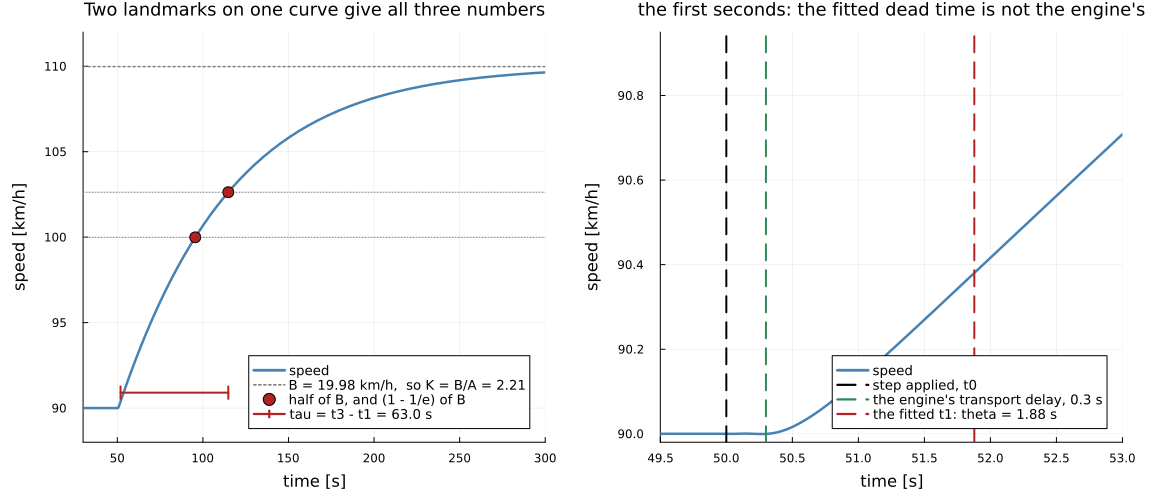

In [5]:
t, v = signal(step_test, "plant.v_kmh")
v_before = v[searchsortedlast(t, T_STEP)]

# The landmarks the fit used, recovered from what it returned rather than measured a second
# time: B is K*A by definition, and t1 is t0 + theta. Drawing them from an independent
# measurement would let the annotation and the numbers disagree.
B = K * A_STEP
t_half = crossing_time(t, v, v_before + 0.5B)
t_63 = crossing_time(t, v, v_before + (1 - exp(-1)) * B)
t_intercept = T_STEP + theta

whole = plot(t, v; lw = 2.5, color = :steelblue, label = "speed",
    xlabel = "time [s]", ylabel = "speed [km/h]", xlims = (T_STEP - 20, 300),
    ylims = (88, 112), legend = :bottomright,
    title = "Two landmarks on one curve give all three numbers")
hline!(whole, [v_before + B]; ls = :dot, lw = 1.5, color = :grey,
    label = "B = $(round(B, digits = 2)) km/h,  so K = B/A = $(round(K, digits = 3))")
hline!(whole, [v_before + 0.5B, v_before + (1 - exp(-1)) * B];
    ls = :dot, lw = 1, color = :grey, label = "")
scatter!(whole, [t_half, t_63], [v_before + 0.5B, v_before + (1 - exp(-1)) * B];
    ms = 6, color = :firebrick, label = "half of B, and (1 - 1/e) of B")
plot!(whole, [t_intercept, t_63], [90.9, 90.9];
    lw = 2, color = :firebrick, marker = :vline, ms = 7,
    label = "tau = t3 - t1 = $(round(tau, digits = 1)) s")

zoom = plot(t, v; lw = 2.5, color = :steelblue, label = "speed",
    xlabel = "time [s]", ylabel = "speed [km/h]",
    xlims = (T_STEP - 0.5, T_STEP + 3), ylims = (89.98, 90.95), legend = :bottomright,
    title = "the first seconds: the fitted dead time is not the engine's")
vline!(zoom, [T_STEP]; ls = :dash, lw = 2, color = :black, label = "step applied, t0")
vline!(zoom, [T_STEP + CAR.theta_e]; ls = :dash, lw = 2, color = :seagreen,
    label = "the engine's transport delay, $(CAR.theta_e) s")
vline!(zoom, [t_intercept]; ls = :dash, lw = 2, color = :firebrick,
    label = "the fitted t1: theta = $(round(theta, digits = 2)) s")

annotated = plot(whole, zoom; layout = (1, 2), size = (1150, 500))
save_figure(annotated, "08-step-test-annotated")
annotated

Two of those three numbers mean what they look like, and the third needs a sentence.

**`K = 2.21 km/h per N.m` and `tau = 63 s` are the car.** Notebook 01 brackets both against
the force balance: the gain sits on the secant across the step, and the time constant between
the 74 s the balance gives at 90 km/h and the 61 s it gives at 110. Neither has a single true
value, because drag is quadratic; the fit returns an average over the interval we tested,
which is the honest thing for it to return.

**`theta = 1.88 s` is not the engine's transport delay.** That delay is 0.3 s and the fit
reports six times it. Nothing is broken. The right panel shows why: the speed is already
moving well before the fitted `t1`, so the curve does not sit still for 1.88 s. What it does is
rise *more slowly than an exponential* at first, because the local time constant is longer at
90 km/h than at 110, and dead time is the only parameter in the FOPTD form that can absorb
that. Shrink the step and the fitted `theta` shrinks with it, because a smaller step spans
less of the curve — which is the tell, since a transport delay does not care how hard you
pushed.

That is a lesson rather than a caveat: **a step test does not know what is inside the plant.**
It reports an *effective* dead time that lumps curvature, unmodeled dynamics and any true
delay into one number. And that is the number the tables want, because the tables are fitted
to the shape of a response, not to a mechanism.

**`r = theta/tau = 0.03` puts this car at the easy end of the scale.** Below about 0.1 a plant
will take almost any gain you offer it; the tables were fitted for 0.1 to 1, and above 1 you
need something cleverer than PID. Worth flagging now, because it is the seed of the third act:
Cohen-Coon's gain is proportional to `tau/theta`, and `tau/theta` here is about 34.


## 3. Cohen-Coon, from the open-loop response

Table 1 of `tuning_methods.pdf`, PID row, with $r = \theta/\tau$:

$$
k = \frac{1}{K}\,\frac{\tau}{\theta}\left(\frac{4}{3} + \frac{r}{4}\right), \qquad
T_i = \theta\,\frac{32 + 6r}{13 + 8r}, \qquad
T_d = \theta\,\frac{4}{11 + 2r}
$$

Three things about that first expression. The dead time is in the *denominator*, so a plant
with no dead time has no Cohen-Coon tuning at all — which is the second reason the engine in
this model carries an explicit transport delay. `1/K` is there because the table returns a gain
in the reciprocal units of the measurement, so feeding it km/h per N.m gives back N.m per km/h,
which is what the loop wants. And nothing else about the car appears anywhere.

From here on the model is `Lecture1.CruiseLoop` with both extra paths built in — the same
assembly as notebooks 04 and 05, source in
[`dyad/Lecture1/CruiseLoop.dyad`](../../dyad/Lecture1/CruiseLoop.dyad), and the plant it closes
around in [`dyad/Vehicle/CarPlant.dyad`](../../dyad/Vehicle/CarPlant.dyad). Run
`show_dyad("CruiseLoop")` in any cell to read the declaration here rather than opening the
file.

Two settings that are not the tuning method's business but change what you see:

- **`wd = 0`** keeps the setpoint out of the derivative path, so the derivative differentiates
  the measurement alone. Differentiating a 20 km/h step commands a torque spike four orders of
  magnitude past the engine, and no cruise control does it. `xd0` starts the derivative filter
  settled at the speed the car is already doing, so the run does not open with a transient of
  its own.
- **The torque ceiling stays lifted**, as it was in notebooks 03 to 05: `T_max` and `y_max` are
  both set far out of the way. These are the gains of the linear design, and they should be
  read as such. Section 8 puts the real engine back.


In [6]:
SPEED = "loop.plant.v_kmh"       # the plant's km/h output, inside the loop harness
COMMAND = "loop.controller.y"    # torque asked of the engine
DELIVERED = "loop.plant.engine.limiter.y"
UNLIMITED = 1.0e6                # N.m — the torque ceiling, lifted out of the way

k_cc, Ti_cc, Td_cc = cohen_coon(K, tau, theta)

pid = Scenarios.CruiseLoopTransient(
    model = Scenarios.CruiseLoopStep(; name = :CruiseLoopStep, with_I = true, with_D = true),
    k = k_cc, Ti = Ti_cc, Td = Td_cc, wd = 0.0,
    T_max = UNLIMITED, y_max = UNLIMITED, stop = 60.0)

# One compiled model for every tuning in this notebook: the three tables differ only in three
# numbers, and `rerun` replaces them in the problem the compiler already built.
tuned(k, Ti, Td, extra::Pair...) = rerun(pid,
    "k" => k, "Ti" => Ti, "Td" => Td, "loop.controller.xd0" => -V_START, extra...)

HEADER = "                     rise [s]  overshoot   settled     peak command"
function readout(name, sol)
    _, y = signal(sol, SPEED)
    _, u = signal(sol, COMMAND)
    peak = maximum(u)
    println("  ", rpad(name, 18),
        rpad(round(rise_time(sol, SETPOINT; sig = SPEED), digits = 2), 10),
        rpad(string(round(overshoot(sol, SETPOINT; sig = SPEED), digits = 1), " %"), 12),
        rpad(round(y[end], digits = 3), 12),
        rpad(string(round(Int, peak), " N.m"), 12),
        round(peak / CAR.T_max, digits = 1), "x the engine")
end

println("Cohen-Coon, from K = ", round(K, digits = 3), ", tau = ", round(tau, digits = 1),
        ", theta = ", round(theta, digits = 3))
println("  k  = ", round(k_cc, digits = 2), " N.m per km/h")
println("  Ti = ", round(Ti_cc, digits = 3), " s")
println("  Td = ", round(Td_cc, digits = 3), " s")
println()
cc = tuned(k_cc, Ti_cc, Td_cc)
println(HEADER)
readout("Cohen-Coon", cc)

Cohen-Coon, from K = 2.21, tau = 63.0, theta = 1.878
  k  = 20.34 N.m per km/h
  Ti = 4.565 s
  Td = 0.679 s

                     rise [s]  overshoot   settled     peak command
  Cohen-Coon        2.54      16.1 %      110.0       407 N.m     2.7x the engine


That is a working cruise controller, computed from three numbers read off a curve. It arrives
at 110 km/h — the integrator sees to that, as notebook 04 explained — in a couple of seconds
against the open-loop car's minute, and it overshoots by 16 %, which is more than a passenger
would enjoy and less than an engineer would call broken. Cohen-Coon is usually quick and
usually a little oscillatory, and this is what that looks like.

Read the last column anyway, because it is the whole third act in one number: the controller
asked for **407 N.m** from an engine that has 150. Park that; section 8 is about it.


## 4. Ziegler-Nichols: walk the gain to the edge

A completely different kind of experiment. Cohen-Coon watched the plant on its own;
Ziegler-Nichols closes the loop, removes the integral and derivative paths, and raises the
proportional gain until the oscillation neither grows nor decays. The gain that does that is
the **ultimate gain** `Ku`, and the period of that oscillation is the **ultimate period** `Pu`.
Two numbers, and two of the three tables in the document consume them.

Notebook 03 has already been to the edge of this without naming it: at `k = 220` the car
overshot to 162 km/h and was still swinging half a minute later, and at `k = 890` it left the
top of the frame. Those gains are past `Ku`. This section finds the boundary they are past.

Three decisions in the cell below, each of which changes what the measurement means:

- **Perturb as little as possible.** The setpoint steps by a tenth of a km/h. A 20 km/h step at
  a gain near the boundary would swing the car across a range where the plant's own gain has
  changed, and what came back would not be the linear oscillation the tables assume. On real
  hardware the same instinct applies for a better reason: you are deliberately destabilizing
  something expensive.
- **Both torque clamps stay lifted.** The engine cannot deliver negative torque — `y_min` is
  nailed to zero in `IdealEngine`, because a petrol engine has no reverse torque path — so an
  oscillation big enough to ask for braking squares off against that clamp and becomes a relay
  limit cycle. That has a period too, and it is not `Pu`.
- **Measure peak-to-trough, not peak-to-mean.** A proportional loop settles *below* its
  setpoint (notebook 03), and it does so on the plant's own minute-long time constant, so the
  oscillation rides on a slow drift for the whole run. The height from each peak to the trough
  after it is immune to that drift; the height above the mean is not.

The readout that matters is the ratio of one cycle's amplitude to the last one's. Below `Ku` it
is less than one, above `Ku` greater, and at `Ku` it is one.


In [7]:
DELTA = 0.1        # km/h — the smallest setpoint poke that still gives a clean measurement

# P-only: `CruiseLoopStep` leaves both structural switches off, so this analysis is the pure
# proportional loop that Ziegler-Nichols step 2 asks for.
probe = Scenarios.CruiseLoopTransient(
    k = 100.0, v_lo = V_START, v_hi = V_START + DELTA,
    T_max = UNLIMITED, y_max = UNLIMITED, stop = 30.0)

function oscillation(sol; from = 4.0)
    t, y = signal(sol, SPEED)
    keep = t .>= from                 # past the step's own first swing
    t, y = t[keep], y[keep]
    peaks = [i for i in 2:(length(y) - 1) if y[i] > y[i - 1] && y[i] >= y[i + 1]]
    amps = [y[p] - minimum(@view y[p:q]) for (p, q) in zip(peaks[1:(end - 1)], peaks[2:end])]
    ratios = amps[2:end] ./ amps[1:(end - 1)]
    return (period = sum(diff(t[peaks])) / (length(peaks) - 1),
            ratio = sum(ratios) / length(ratios))
end

GAINS = [80.0, 100.0, 110.0, 112.0, 114.0, 115.0, 125.0]
ladder = sweep(probe, "k", GAINS)

# The lowest command is the validity check, not decoration: a run that reached zero asked the
# engine for braking torque it does not have, and what it did after that is a limit cycle
# against that clamp rather than the linear oscillation the tables are about.
walk = [(k = k, osc = oscillation(sol), floor = minimum(signal(sol, COMMAND)[2]), sol = sol)
        for (k, sol) in ladder]

println("  k        period [s]   amplitude ratio per cycle   lowest command [N.m]")
for w in walk
    println("  ", rpad(w.k, 9), rpad(round(w.osc.period, digits = 3), 13),
            rpad(round(w.osc.ratio, digits = 4), 28), round(w.floor, digits = 2))
end

  k        period [s]   amplitude ratio per cycle   lowest command [N.m]
  80.0     2.509        0.4265                      8.0
  100.0    2.294        0.7367                      10.0
  110.0    2.219        0.9136                      11.0
  112.0    2.197        0.9531                      11.2
  114.0    2.177        0.989                       11.4
  115.0    2.173        1.0087                      9.03
  125.0    2.178        1.0383                      0.0


ultimate gain    Ku = 114.56 N.m per km/h
ultimate period  Pu = 2.175 s
amplitude ratio at Ku = 0.99967 — neither growing nor decaying


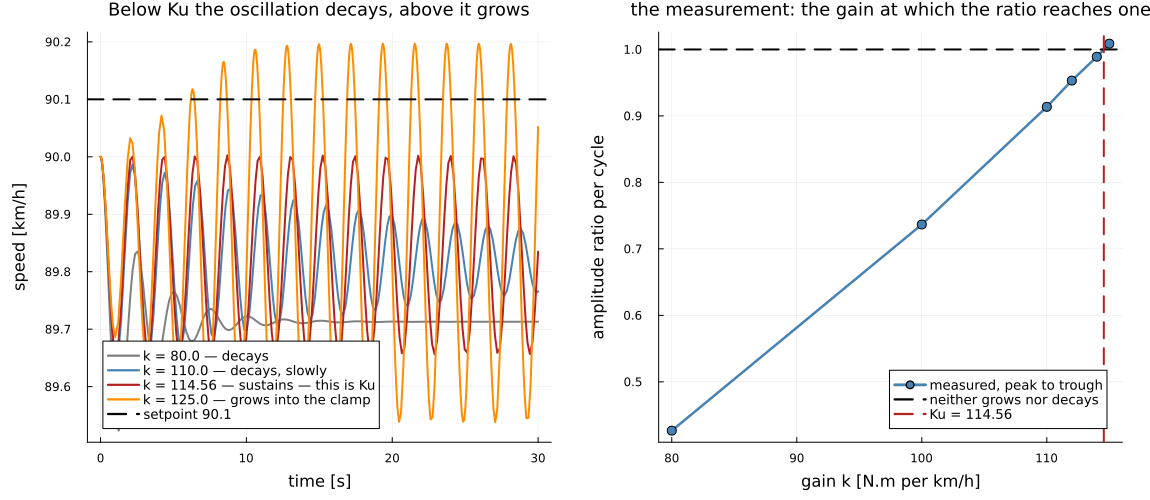

In [8]:
# Read the crossing off the ladder rather than declaring a run "sustained" by eye: the ratio is
# monotonic in the gain, so the gain at which it reaches one is a straight interpolation between
# the two runs either side of it.
usable = filter(w -> w.floor > 0, walk)
crossing = findlast(w -> w.osc.ratio < 1, usable)
below, above = usable[crossing], usable[crossing + 1]

Ku = below.k + (1 - below.osc.ratio) * (above.k - below.k) / (above.osc.ratio - below.osc.ratio)
at_Ku = rerun(probe, "k" => Ku)
Pu = oscillation(at_Ku).period

println("ultimate gain    Ku = ", round(Ku, digits = 2), " N.m per km/h")
println("ultimate period  Pu = ", round(Pu, digits = 3), " s")
println("amplitude ratio at Ku = ", round(oscillation(at_Ku).ratio, digits = 5),
        " — neither growing nor decaying")

traces = plot(; xlabel = "time [s]", ylabel = "speed [km/h]", legend = :bottomleft,
    title = "Below Ku the oscillation decays, above it grows")
solved_at(k) = walk[findfirst(w -> w.k == k, walk)].sol
for (k, sol, color, note) in ((80.0, solved_at(80.0), :grey, "decays"),
                              (110.0, solved_at(110.0), :steelblue, "decays, slowly"),
                              (Ku, at_Ku, :firebrick, "sustains — this is Ku"),
                              (125.0, solved_at(125.0), :darkorange, "grows into the clamp"))
    plot!(traces, signal(sol, SPEED)...; lw = 2, color,
          label = "k = $(round(k, digits = 2)) — $note")
end
hline!(traces, [V_START + DELTA]; ls = :dash, lw = 2, color = :black,
       label = "setpoint $(V_START + DELTA)")

growth = plot([w.k for w in usable], [w.osc.ratio for w in usable];
    lw = 2.5, color = :steelblue, marker = :circle, ms = 5, legend = :bottomright,
    label = "measured, peak to trough", xlabel = "gain k [N.m per km/h]",
    ylabel = "amplitude ratio per cycle",
    title = "the measurement: the gain at which the ratio reaches one")
hline!(growth, [1.0]; ls = :dash, lw = 2, color = :black, label = "neither grows nor decays")
vline!(growth, [Ku]; ls = :dash, lw = 2, color = :firebrick,
       label = "Ku = $(round(Ku, digits = 2))")

oscillation_fig = plot(traces, growth; layout = (1, 2), size = (1150, 500))
save_figure(oscillation_fig, "08-ultimate-oscillation")
oscillation_fig

The left panel is the experiment as a lecturer would run it: raise the gain, watch the
oscillation take longer and longer to die, and stop when it stops dying. The right panel is the
same thing as a measurement — the per-cycle amplitude ratio crosses one at `Ku`, and reading
the crossing off a plot is both more honest and more repeatable than deciding by eye that a
trace "looks sustained".

The `k = 125` run is above `Ku`, and its lowest command is zero: the oscillation grew until the
controller asked the engine for braking torque it does not have. Past that point the run is a
relay limit cycle against the clamp rather than a linear oscillation, which is why that run is
left out of the crossing on the right — and why, on hardware, the growing case is the one you
must not sit in.

Table 2 of the document turns the two numbers into gains:

| from `Ku` and `Pu` | `k` | `Ti` | `Td` |
|---|---|---|---|
| P | $K_u/2$ | — | — |
| PI | $K_u/2.2$ | $P_u/1.2$ | — |
| **PID** | $K_u/1.7$ | $P_u/2$ | $P_u/8$ |

Two things worth noticing before applying it. Adding paths *lowers* the gain you are allowed —
the integral spends phase margin, so you have to give gain back. And `Ti` is four times `Td` in
every row, whatever `Pu` is, so Ziegler-Nichols always puts the two zeros in the same place
relative to each other and only slides them with the measured period. That is the whole content
of the method.

What the numbers encode is a **quarter-amplitude decay**: each overshoot a quarter of the one
before. That was a reasonable target for a 1940s process plant. It is far more oscillatory than
anyone wants in a vehicle, and the next cell shows exactly that.


In [9]:
k_zn, Ti_zn, Td_zn = ziegler_nichols(Ku, Pu)

println("Ziegler-Nichols, from Ku = ", round(Ku, digits = 2), " and Pu = ", round(Pu, digits = 3))
println("  k  = ", rpad(round(k_zn, digits = 2), 8), " N.m per km/h    = Ku/1.7")
println("  Ti = ", rpad(round(Ti_zn, digits = 3), 8), " s                = Pu/2")
println("  Td = ", rpad(round(Td_zn, digits = 3), 8), " s                = Pu/8")
println()
zn = tuned(k_zn, Ti_zn, Td_zn)
println(HEADER)
readout("Cohen-Coon", cc)
readout("Ziegler-Nichols", zn)

Ziegler-Nichols, from Ku = 114.56 and Pu = 2.175
  k  = 67.39    N.m per km/h    = Ku/1.7
  Ti = 1.087    s                = Pu/2
  Td = 0.272    s                = Pu/8

                     rise [s]  overshoot   settled     peak command
  Cohen-Coon        2.54      16.1 %      110.0       407 N.m     2.7x the engine
  Ziegler-Nichols   0.53      46.8 %      110.0       1356 N.m    9.0x the engine


Quarter-amplitude decay, as advertised: the car arrives in half a second and overshoots to
119 km/h on its way. A passenger would notice, and the engine is being asked for 1356 N.m.

## 5. Tyreus-Luyben: the same measurement, a calmer answer

The third table in the same document, fed the same `Ku` and `Pu`:

| same `Ku`, `Pu` | `k` | `Ti` | `Td` |
|---|---|---|---|
| PI | $K_u/3.2$ | $2.2\,P_u$ | — |
| **PID** | $K_u/2.2$ | $2.2\,P_u$ | $P_u/6.3$ |

There is no P row: the method exists in order to be gentler, and a P controller has nothing to
be gentle with.

Three quarters of Ziegler-Nichols' gain, and look at the `Ti` column — this is the one place
where the two tables disagree about *direction*. Ziegler-Nichols divides the ultimate period by
two; Tyreus-Luyben multiplies it by 2.2. That is a factor of 4.4 in integrator speed, out of
the same experiment.

Which tells you something more useful than either table: **a tuning rule encodes somebody's
requirements, not a law of nature.** Ziegler and Nichols wanted a fast recovery on a 1940s
process plant and accepted the ringing. Tyreus and Luyben wanted margin. If neither set of
requirements is yours, neither table is yours either.


In [10]:
k_tl, Ti_tl, Td_tl = tyreus_luyben(Ku, Pu)

println("Tyreus-Luyben, from the same Ku and Pu")
println("  k  = ", rpad(round(k_tl, digits = 2), 8), " N.m per km/h    = Ku/2.2")
println("  Ti = ", rpad(round(Ti_tl, digits = 3), 8), " s                = 2.2*Pu")
println("  Td = ", rpad(round(Td_tl, digits = 3), 8), " s                = Pu/6.3")
println()
tl = tuned(k_tl, Ti_tl, Td_tl)
println(HEADER)
readout("Cohen-Coon", cc)
readout("Ziegler-Nichols", zn)
readout("Tyreus-Luyben", tl)

Tyreus-Luyben, from the same Ku and Pu
  k  = 52.07    N.m per km/h    = Ku/2.2
  Ti = 4.784    s                = 2.2*Pu
  Td = 0.345    s                = Pu/6.3

                     rise [s]  overshoot   settled     peak command
  Cohen-Coon        2.54      16.1 %      110.0       407 N.m     2.7x the engine
  Ziegler-Nichols   0.53      46.8 %      110.0       1356 N.m    9.0x the engine
  Tyreus-Luyben     0.81      7.6 %       110.0       1042 N.m    6.9x the engine


## 6. All three on one axes

One plant, one step test, three tables, three answers that do not agree. That disagreement is
the honest state of heuristic tuning, and it is worth looking at rather than hiding.


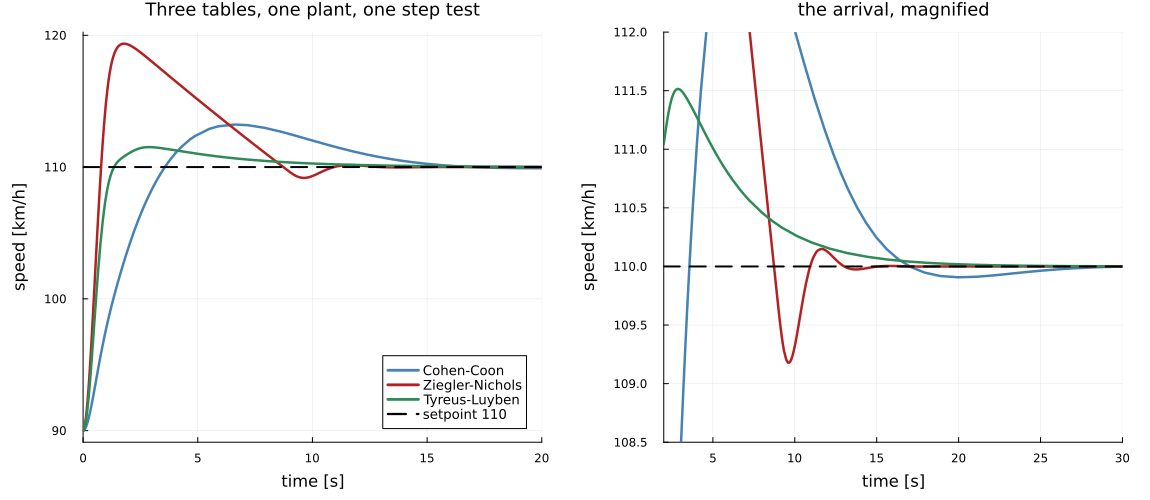

In [11]:
TUNINGS = ["Cohen-Coon" => cc, "Ziegler-Nichols" => zn, "Tyreus-Luyben" => tl]
COLORS = [:steelblue, :firebrick, :seagreen]

step = plot(; xlabel = "time [s]", ylabel = "speed [km/h]", xlims = (0, 20),
    title = "Three tables, one plant, one step test", legend = :bottomright)
arrival = plot(; xlabel = "time [s]", ylabel = "speed [km/h]", xlims = (2, 30),
    ylims = (108.5, 112), legend = false, title = "the arrival, magnified")
for ((name, sol), color) in zip(TUNINGS, COLORS)
    plot!(step, signal(sol, SPEED)...; lw = 2.5, color, label = name)
    plot!(arrival, signal(sol, SPEED)...; lw = 2.5, color, label = name)
end
hline!(step, [SETPOINT];
    ls = :dash, lw = 2, color = :black, label = "setpoint $(round(Int, SETPOINT))")
hline!(arrival, [SETPOINT]; ls = :dash, lw = 2, color = :black, label = "")

three = plot(step, arrival; layout = (1, 2), size = (1150, 500))
save_figure(three, "08-three-tunings")
three

**Which of these would you ship?** On this plot the answer is Tyreus-Luyben and it is not
close: it arrives three times faster than Cohen-Coon, overshoots less than half as much, and
settles without the ringing Ziegler-Nichols was designed to accept. Ziegler-Nichols is doing
exactly what its authors asked of it, on a plant that is not a 1940s distillation column, in a
vehicle whose passengers have opinions.

Notice also what none of the three did: use the mass of the car, its drag area or its gear
ratio. A method that needs no model is a method you can use on hardware somebody else built,
and that is the whole reason these tables have outlived the plants they were fitted to.

And then look at the last column of the table above one more time, because the plot is lying to
you by omission. Every one of those three responses was produced by an engine that does not
exist.


## 7. Why Ziegler-Nichols is dangerous on real hardware

The method requires driving the plant deliberately to the edge of instability and sitting there
long enough to measure a period. In this notebook that cost a re-run. Elsewhere:

| On | Acceptable? |
|---|---|
| a simulation | free — make it unstable, it costs a solve |
| a thermal chamber | usually, with a thermal cut-out and nobody in the room |
| a vehicle at 110 km/h on a public road, with a passenger | **no** |

This is why Cohen-Coon exists: an open-loop step test never leaves the stable region, so the
worst it can do is heat something up or make it go faster than you wanted. It is the method you
may run on a customer's machine, in their factory, on their product.

There is also a middle route, and it is the one this notebook just took without remarking on
it: **run Ziegler-Nichols on a model, then take the gains to the hardware.** You get the
measurement without the risk, at the price of trusting the model near the stability boundary —
which is precisely where models are least trustworthy, because that is where the small lags
nobody modeled decide the answer. There is no free lunch in that trade. There is just a cheaper
lunch.

The genuinely safe way to get `Ku` is the fourth method in the document, the **relay
autotune**: replace the controller with a relay that swings the output by $\pm d$ around the
operating point, let the loop limit-cycle, measure the output amplitude $a$ and the period, and
read

$$
K_u \;=\; \frac{4d}{\pi a}
$$

which is the describing-function approximation of the relay — a square wave of height $d$ has a
first harmonic of $4d/\pi$. You choose $d$, so you choose how hard the plant is shaken, and the
oscillation is bounded by construction rather than by your reflexes. That is what the autotune
button on industrial hardware is doing, and it is why your thermal chamber has one and your car
does not have a "raise the gain until it oscillates" button. We do not run it here: it needs a
relay block this model does not have, and it would tell us what the gain ladder already told
us.


## 8. The saturation trap

Here is the plot that should have been drawn four sections ago. Same three tunings, same step —
but the commanded torque instead of the speed, with the engine's real ceiling drawn on.


with the engine's 150 N.m limit in place
                     rise [s]  overshoot   settled     peak command
  Cohen-Coon        4.24      15.3 %      110.0       150 N.m     1.0x the engine
  Ziegler-Nichols   4.23      11.3 %      110.0       150 N.m     1.0x the engine
  Tyreus-Luyben     4.23      6.8 %       110.0       150 N.m     1.0x the engine


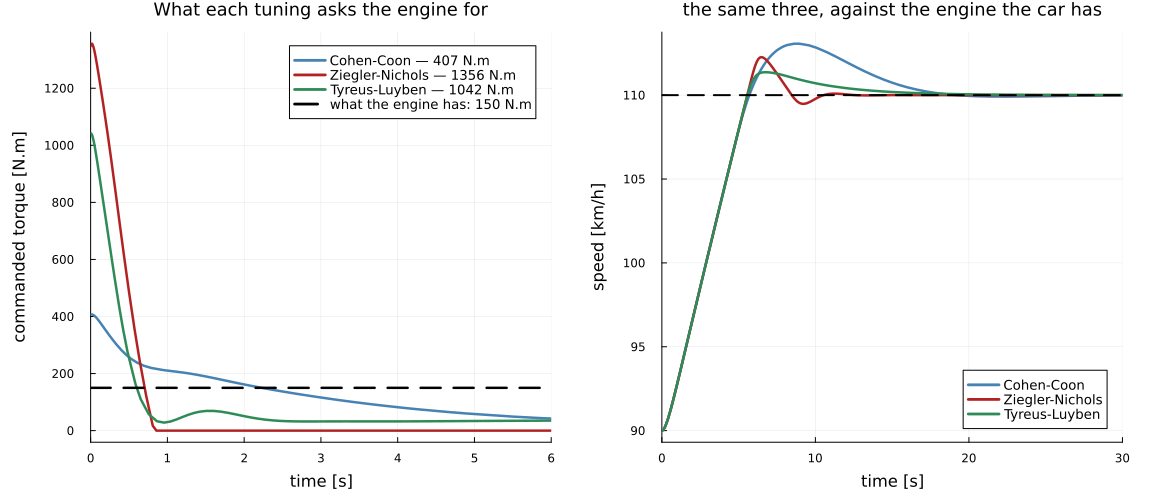

In [12]:
# The real engine, in the model that has been running without one: `T_max` is the plant's
# ceiling and `y_max` the controller's own output clamp, and both go back to 150 N.m.
limited = [name => tuned(k, Ti, Td, "T_max" => CAR.T_max, "y_max" => CAR.T_max)
           for (name, (k, Ti, Td)) in ["Cohen-Coon" => (k_cc, Ti_cc, Td_cc),
                                       "Ziegler-Nichols" => (k_zn, Ti_zn, Td_zn),
                                       "Tyreus-Luyben" => (k_tl, Ti_tl, Td_tl)]]

ask = plot(; xlabel = "time [s]", ylabel = "commanded torque [N.m]", xlims = (0, 6),
    title = "What each tuning asks the engine for", legend = :topright)
for ((name, sol), color) in zip(TUNINGS, COLORS)
    _, u = signal(sol, COMMAND)
    plot!(ask, signal(sol, COMMAND)...; lw = 2.5, color,
        label = "$name — $(round(Int, maximum(u))) N.m")
end
hline!(ask, [CAR.T_max]; ls = :dash, lw = 2.5, color = :black,
    label = "what the engine has: $(round(Int, CAR.T_max)) N.m")

got = plot(; xlabel = "time [s]", ylabel = "speed [km/h]", xlims = (0, 30),
    title = "the same three, against the engine the car has", legend = :bottomright)
for ((name, sol), color) in zip(limited, COLORS)
    plot!(got, signal(sol, SPEED)...; lw = 2.5, color, label = name)
end
hline!(got, [SETPOINT]; ls = :dash, lw = 2, color = :black, label = "")

trap = plot(ask, got; layout = (1, 2), size = (1150, 500))
save_figure(trap, "08-saturation-trap")

println("with the engine's 150 N.m limit in place")
println(HEADER)
for (name, sol) in limited
    readout(name, sol)
end
trap

**The left panel is the trap.** Nothing in the speed plot hinted at it. There was no error, no
warning, no red line — the linear model accepted a controller that asks for nine times the
torque the engine can produce and reported a beautiful response. A simulation can be internally
consistent and completely useless at the same time, and the only cheap defense is the rule this
section exists to teach: **always plot the actuator command.**

**The right panel is more interesting than "the beautiful response disappears".** Put the real
engine back and the three tunings very nearly converge. They have to: for the first seconds all
three are asking for more torque than there is, so all three get exactly 150 N.m, and a car
being given 150 N.m accelerates the way a car being given 150 N.m accelerates. The tuning that
was three times over and the tuning that was nine times over produce the same opening second,
because the engine — not the table — is setting the response. The afternoon you spent choosing
between them bought less than the plot in section 6 suggested.

That they recover *gracefully* is not luck either, and it is worth naming: `LimPID` has
back-calculation anti-windup built in, so when the output is pinned at the limit the integrator
stops accumulating the error it cannot act on. That mechanism is notebook 06's whole subject,
and it is already doing real work here. Without it, every one of these three designs would also
wind up, and the overshoot on the right would be far worse than what you see.


### How much controller actually fits inside this engine?

This is arithmetic, not simulation, and it is short enough to do in front of the room.

Holding 110 km/h takes about 40 N.m. A proportional path commands `k` times the error, and at
the instant a 20 km/h step lands the error *is* 20 km/h, so the command is `20k`. Staying inside
150 N.m therefore needs

$$
k \;\le\; \frac{150}{20} \;=\; 7.5 \ \text{N.m per km/h}
$$

and every gain the three tables just produced — 20.3, 52.1, 67.4 — is between three and nine
times that. There is no tuning of this loop that both crosses a 20 km/h step and stays inside
the actuator, and no table is at fault: the ratio of the torque needed to *hold* the new speed
to the torque available sets the largest step a proportional path can cover, and 20 km/h is too
big a step for this engine.

The cell below runs the gain that fits, and reports what it costs.


In [13]:
k_fits = CAR.T_max / (SETPOINT - V_START)      # N.m per km/h

# Where a proportional loop settles: the error that buys exactly the torque the new speed needs,
# solved as a fixed point of e = T_cruise(v_set - e)/k. This is notebook 03's section 4.
function settled_error(k; v_set = SETPOINT)
    e = 0.0
    for _ in 1:40
        e = cruise_torque(v_set - e) / k
    end
    return e
end

p_real = Scenarios.CruiseLoopTransient(
    k = k_fits, T_max = CAR.T_max, y_max = CAR.T_max, stop = 400.0)

println("  k        peak command   delivered   settled [km/h]   error [km/h]   predicted")
for k in (5.0, k_fits, 14.0)
    sol = rerun(p_real, "k" => k)
    _, y = signal(sol, SPEED)
    _, u = signal(sol, COMMAND)
    _, d = signal(sol, DELIVERED)
    println("  ", rpad(round(k, digits = 2), 9),
            rpad(string(round(Int, maximum(u)), " N.m"), 15),
            rpad(round(maximum(d), digits = 1), 12),
            rpad(round(y[end], digits = 3), 17),
            rpad(round(steady_state_error(sol, SETPOINT; sig = SPEED), digits = 3), 15),
            round(settled_error(k), digits = 3))
end

  k        peak command   delivered   settled [km/h]   error [km/h]   predicted
  5.0      100 N.m        94.9        102.68           7.32           7.32
  7.5      150 N.m        139.3       104.976          5.024          5.024
  14.0     150 N.m        150.0       107.231          2.769          2.769


So the gain that just fits inside the engine leaves the car **5 km/h short** of the speed it was
asked for, which is a cruise control nobody would ship for the opposite reason. Above it the
command is clamped rather than obeyed, which is the same trap in a smaller coat: `k = 14`, the
gentlest gain in notebook 03's family, would ask for 280 N.m on this step, and the column reads
150 because that is all the clamp will pass.

## 9. What to do instead

Three sentences, and the first is the one to keep.

**Always plot the actuator command.** It is one extra line in a notebook and it is the
difference between a design and a drawing.

**A heuristic table gives you a starting point, not a controller.** It got us into the right
decade from one experiment, which is exactly what it promises and no more. The last factor of
two is yours, and on this car so is the first factor of nine.

**And the fix for this particular wall is not a better table.** Two things actually work, and
neither is a tuning:

- **Anti-windup**, so that the controller behaves sensibly while the engine is saturated
  instead of accumulating a debt it will pay back as overshoot. It was already running in the
  right-hand panel above, which is why that panel looks as good as it does — and it is
  **notebook 06**.
- **Ramp the setpoint instead of stepping it.** A 20 km/h step is not a thing a driver can ask
  for: press resume on a real cruise control and the car does not lurch, it accelerates at
  something like 1 km/h per second. At that rate the error never exceeds a km/h or two, the
  proportional path never asks for more than the engine has, and every one of these three
  tunings behaves. Production cruise control does not solve this problem with gains. It solves
  it by never presenting the loop with the step in the first place.

A tidier ending was available — pick the gain set that looks best, declare it tuned, move on.
It would also have been a lie, and one the students could check with a plot they already know
how to draw.


## What this bought us

A gain set out of one step test, with no model of the car in the calculation; a second gain set
out of an experiment that never mentions the car either; three answers that disagree, and a
reason to prefer one of them. And the rule that outlives all three tables: plot the command,
every time.

**Notebook 09** takes the gains from this notebook and changes one thing that has been quietly
assumed throughout — that the controller is watching continuously. It is not; it runs on a
computer that looks, computes, commands, and then does nothing at all until the next tick. The
same controller gets worse purely because it looks less often, and the ultimate period measured
here is what tells you how much less often you can afford.
